# Exploratory Data Analysis cho 3 split: `train`, `val`, `test`

Notebook này EDA đồng nhất cho cả 3 file `train.parquet`, `val.parquet`, `test.parquet` của bài toán tóm tắt văn bản tiếng Việt. Nội dung chính gồm: kiểm tra schema, missing/empty values, duplicate, thống kê độ dài văn bản, tỷ lệ nén summary/article, outlier, phân phối giữa các split, token phổ biến và kiểm tra trùng lặp giữa các split.

> Chỉ cần đặt 3 file parquet cùng thư mục với notebook hoặc trong thư mục `data/`, sau đó chạy lần lượt từ trên xuống.

## 1. Cài đặt thư viện

Nếu môi trường chưa có `pyarrow`, `seaborn`, hãy bỏ comment cell dưới đây và chạy một lần, sau đó restart runtime/kernel.

In [1]:
# Uncomment nếu môi trường thiếu thư viện đọc parquet hoặc vẽ biểu đồ.
# %pip install -q pandas pyarrow matplotlib seaborn

## 2. Import và cấu hình hiển thị

In [2]:
from pathlib import Path
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

## 3. Khai báo đường dẫn và load 3 file

Cell này tìm file theo nhiều vị trí phổ biến: cùng thư mục notebook, `data/`, `../data/`, `/content/`, `/content/data/`, `/mnt/data/`. Nếu bạn dùng Google Colab và lưu file ở Drive, có thể thêm đường dẫn Drive vào `extra_candidates`.

In [3]:
def find_data_path(filename: str, extra_candidates=None) -> Path:
    # Tìm file dữ liệu theo các vị trí phổ biến trên local/Colab/Kaggle.
    extra_candidates = extra_candidates or []
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("..") / "data" / filename,
        Path("/content") / filename,
        Path("/content") / "data" / filename,
        Path("/mnt/data") / filename,
        *[Path(p) for p in extra_candidates],
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Không tìm thấy {filename}. Đã thử: {candidates}")

# Thứ tự hiển thị cố định để dễ so sánh.
SPLIT_FILES = {
    "train": "train.parquet",
    "val": "val.parquet",
    "test": "test.parquet",
}

paths = {split: find_data_path(filename) for split, filename in SPLIT_FILES.items()}
paths

{'train': PosixPath('data/train.parquet'),
 'val': PosixPath('data/val.parquet'),
 'test': PosixPath('data/test.parquet')}

In [4]:
dfs = {split: pd.read_parquet(path) for split, path in paths.items()}

size_summary = pd.DataFrame([
    {
        "split": split,
        "path": str(paths[split]),
        "rows": len(df),
        "columns": df.shape[1],
        "column_names": ", ".join(df.columns.astype(str)),
    }
    for split, df in dfs.items()
]).set_index("split")

display(size_summary)

for split, df in dfs.items():
    print(f"\n===== {split.upper()} | shape={df.shape} =====")
    display(df.head(3))

,path,rows,columns,column_names
split,,,,
train,data/train.parquet,10775,2,"article, summary"
val,data/val.parquet,1349,2,"article, summary"
test,data/test.parquet,1344,2,"article, summary"



===== TRAIN | shape=(10775, 2) =====


,article,summary
0,"Gần 20 sự kiện được tổ chức trên toàn thành phố, kéo dài từ 19/4 đến 10/5. Theo Sở Du lịch Hà Nội, ngoài thu hút du khách, loạt sự kiện cũng là các gợi ý dà...","Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5, bao gồm Lễ hội Du lịch Hà Nội 2024, các triển lãm và lễ hội văn hóa, nhằm thu hút cả du khách và người dân. ..."
1,"Được thành lập năm 1897 tại Đức, Kempinski Hotels là thương hiệu nổi tiếng trong lĩnh vực nghỉ dưỡng, được sở hữu bởi hai hoàng gia Trung Đông và châu Á. Tr...","Kempinski Hotels là một thương hiệu nổi tiếng trong lĩnh vực nghỉ dưỡng, được thành lập năm 1897 tại Đức. Với hơn 127 năm lịch sử, Kempinski đã trở thành đi..."
2,"Ngoài di chuyển đến Tuần Châu bằng đường bộ, mọi người có thể thử đi phà. Bến phà Tuần Châu nằm ngay trung tâm Bãi Cháy, thuận tiện trong lịch trình. Một tr...","Bài viết giới thiệu các hoạt động vui chơi giải trí tại Tuần Châu dịp 30/4, bao gồm đi phà đến đảo, tham quan Harmony Hill với mini show ""Sóng Tình"" của ca ..."



===== VAL | shape=(1349, 2) =====


,article,summary
0,Giải thưởng công bố gần đây bởi World Travel Awards. Đây là năm thứ hai liên tiếp InterContinental Phu Quoc Long Beach Resort được vinh danh ở hạng mục gia ...,InterContinental Phu Quoc Long Beach Resort đã được vinh danh là khu nghỉ dưỡng gia đình tốt nhất châu Á lần thứ 2 liên tiếp. Khu nghỉ dưỡng này tọa lạc bên...
1,"Theo bảng xếp hạng 20 quốc gia tốt nhất thế giới năm 2024 (The Best Countries in the World) do tạp chí du lịch Mỹ Condé Nast Traveler công bố vào tháng 10, ...","Việt Nam đã xếp hạng 15 trên bảng xếp hạng 20 quốc gia tốt nhất thế giới năm 2024 với 89 điểm. Thái Lan xếp hạng thứ 3 với 92,29 điểm. Nhật Bản đứng đầu bản..."
2,"Ngày hội Văn hóa, Thể thao và Du lịch các dân tộc vùng Đông Bắc lầnthứ 11 năm nay có chủ đề 'Văn hóa vùng Đông Bắc -Bản sắc, hội nhập và vươn xa'. Đây là sự...","Ngày hội Văn hóa, Thể thao và Du lịch các dân tộc vùng Đông Bắc là sự kiện thường niên quy mô lớn, được tổ chức tại tỉnh Lạng Sơn. Năm nay, sự kiện này có c..."



===== TEST | shape=(1344, 2) =====


,article,summary
0,"Văn phòng mới của MayTrip tại địa chỉ 833 Lê Hồng Phong, quận 10, nhằm mở rộng dịch vụ và nâng cao trải nghiệm khách hàng khu vực phía Nam. Văn phòng mới đư...","MayTrip khai trương văn phòng mới tại TP. HCM (833 Lê Hồng Phong, quận 10) nhằm mở rộng dịch vụ và nâng cao trải nghiệm khách hàng khu vực phía Nam. Sự kiệ..."
1,"Đầu tháng 11, dã quỳ bung nở trên các vạt núi và cung đường dẫn lên Vườn quốc gia Ba Vì. Dã quỳ tại đây được người Pháp trồng khoảng những năm 1930 - 1945. ...","Rừng hoa dã quỳ ở Vườn quốc gia Ba Vì rộng khoảng 10 ha, được người Pháp trồng vào khoảng những năm 1930-1945. Đầu tháng 11, hoa dã quỳ bắt đầu bung nở, tạo..."
2,"Mùa thu đông năm nay, Tam Cốc đặc biệt và hấp dẫn hơn trong mắt du khách nhờ cánh đồng hoa súng nở rộ hai bên sông Ngô Đồng. Hoa súng bung nở đẹp hơn dưới á...","Mùa thu đông năm nay, Tam Cốc đặc biệt và hấp dẫn hơn trong mắt du khách nhờ cánh đồng hoa súng nở rộ hai bên sông Ngô Đồng. Hoa súng bung nở đẹp hơn dưới á..."


## 4. Kiểm tra schema, missing values và số giá trị duy nhất

In [5]:
def schema_quality_table(df: pd.DataFrame, split: str) -> pd.DataFrame:
    table = pd.DataFrame({
        "split": split,
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing": df.isna().sum().values,
        "missing_pct": df.isna().mean().mul(100).round(2).values,
        "n_unique": df.nunique(dropna=True).values,
    })
    return table

schema_summary = pd.concat(
    [schema_quality_table(df, split) for split, df in dfs.items()],
    ignore_index=True,
)

display(schema_summary)

,split,column,dtype,missing,missing_pct,n_unique
0,train,article,object,0,0.0,10775
1,train,summary,object,0,0.0,10775
2,val,article,object,0,0.0,1349
3,val,summary,object,0,0.0,1349
4,test,article,object,0,0.0,1344
5,test,summary,object,0,0.0,1344


## 5. Kiểm tra duplicate, empty text và whitespace text

Với bài toán tóm tắt văn bản, các lỗi thường cần kiểm tra là: dòng bị trùng hoàn toàn, `article`/`summary` rỗng, hoặc văn bản chỉ gồm khoảng trắng.

In [6]:
TEXT_COLUMNS = ["article", "summary"]

def quality_checks(df: pd.DataFrame, split: str) -> dict:
    row = {
        "split": split,
        "rows": len(df),
        "duplicate_rows": int(df.duplicated().sum()),
        "duplicate_rows_pct": round(df.duplicated().mean() * 100, 2),
    }
    for col in TEXT_COLUMNS:
        if col in df.columns:
            as_text = df[col].fillna("").astype(str)
            stripped = as_text.str.strip()
            row[f"{col}_missing"] = int(df[col].isna().sum())
            row[f"{col}_empty_or_whitespace"] = int(stripped.eq("").sum())
            row[f"{col}_duplicated"] = int(df[col].duplicated().sum())
            row[f"{col}_duplicated_pct"] = round(df[col].duplicated().mean() * 100, 2)
        else:
            row[f"{col}_missing"] = pd.NA
            row[f"{col}_empty_or_whitespace"] = pd.NA
            row[f"{col}_duplicated"] = pd.NA
            row[f"{col}_duplicated_pct"] = pd.NA
    return row

quality_summary = pd.DataFrame([quality_checks(df, split) for split, df in dfs.items()]).set_index("split")
display(quality_summary)

,rows,duplicate_rows,duplicate_rows_pct,article_missing,article_empty_or_whitespace,article_duplicated,article_duplicated_pct,summary_missing,summary_empty_or_whitespace,summary_duplicated,summary_duplicated_pct
split,,,,,,,,,,,
train,10775,0,0.0,0,0,0,0.0,0,0,0,0.0
val,1349,0,0.0,0,0,0,0.0,0,0,0,0.0
test,1344,0,0.0,0,0,0,0.0,0,0,0,0.0


## 6. Kiểm tra trùng lặp giữa các split

Cell này giúp phát hiện data leakage dạng trùng `article` hoặc trùng cặp `(article, summary)` giữa train/val/test.

In [7]:
def overlap_count(left: pd.DataFrame, right: pd.DataFrame, columns: list[str]) -> int:
    available_cols = [col for col in columns if col in left.columns and col in right.columns]
    if not available_cols:
        return 0
    left_keys = set(map(tuple, left[available_cols].fillna("").astype(str).values.tolist()))
    right_keys = set(map(tuple, right[available_cols].fillna("").astype(str).values.tolist()))
    return len(left_keys & right_keys)

split_names = list(dfs.keys())
overlap_rows = []
for i, split_a in enumerate(split_names):
    for split_b in split_names[i + 1:]:
        row = {
            "split_a": split_a,
            "split_b": split_b,
            "same_article": overlap_count(dfs[split_a], dfs[split_b], ["article"]),
            "same_summary": overlap_count(dfs[split_a], dfs[split_b], ["summary"]),
            "same_article_summary_pair": overlap_count(dfs[split_a], dfs[split_b], ["article", "summary"]),
        }
        overlap_rows.append(row)

overlap_summary = pd.DataFrame(overlap_rows)
display(overlap_summary)

,split_a,split_b,same_article,same_summary,same_article_summary_pair
0,train,val,0,0,0
1,train,test,0,0,0
2,val,test,0,0,0


## 7. Tạo đặc trưng độ dài văn bản

Các đặc trưng chính:

- `article_chars`, `summary_chars`: số ký tự.
- `article_words`, `summary_words`: số token/từ đơn giản theo regex Unicode.
- `summary_to_article_word_ratio`: tỷ lệ độ dài summary trên article, càng thấp thường là mức nén càng mạnh.

In [8]:
def word_count(series: pd.Series) -> pd.Series:
    # Regex \w trong Python hỗ trợ Unicode, phù hợp tương đối cho tiếng Việt có dấu.
    return series.fillna("").astype(str).str.findall(r"\b\w+\b").str.len()

def add_text_features(df: pd.DataFrame) -> pd.DataFrame:
    eda_df = df.copy()
    if "article" in eda_df.columns:
        eda_df["article_chars"] = eda_df["article"].fillna("").astype(str).str.len()
        eda_df["article_words"] = word_count(eda_df["article"])
    if "summary" in eda_df.columns:
        eda_df["summary_chars"] = eda_df["summary"].fillna("").astype(str).str.len()
        eda_df["summary_words"] = word_count(eda_df["summary"])
    if {"article_words", "summary_words"}.issubset(eda_df.columns):
        eda_df["summary_to_article_word_ratio"] = (
            eda_df["summary_words"] / eda_df["article_words"].replace(0, pd.NA)
        )
    return eda_df

eda_dfs = {split: add_text_features(df) for split, df in dfs.items()}
combined_eda = pd.concat(
    [df.assign(split=split) for split, df in eda_dfs.items()],
    ignore_index=True,
)

length_cols = [
    col for col in [
        "article_chars", "summary_chars",
        "article_words", "summary_words",
        "summary_to_article_word_ratio",
    ]
    if col in combined_eda.columns
]

combined_eda[["split", *length_cols]].head()

,split,article_chars,summary_chars,article_words,summary_words,summary_to_article_word_ratio
0,train,1599,350,362,84,0.232044
1,train,3237,712,677,148,0.218612
2,train,2161,428,468,93,0.198718
3,train,2176,397,473,88,0.186047
4,train,1786,425,392,99,0.252551


## 8. Thống kê độ dài theo từng split

In [9]:
length_describe = (
    combined_eda
    .groupby("split")[length_cols]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)

display(length_describe)

split                                       test         train          val
article_chars                 count  1344.000000  10775.000000  1349.000000
                              mean   2200.094494   2128.281578  2166.088955
                              std     474.940296    464.814019   474.892213
                              min    1312.000000   1286.000000  1319.000000
                              1%     1416.290000   1394.000000  1397.440000
                              5%     1503.150000   1484.000000  1503.000000
                              25%    1837.750000   1768.000000  1804.000000
                              50%    2140.000000   2061.000000  2085.000000
                              75%    2549.500000   2402.500000  2462.000000
                              95%    3080.950000   3042.000000  3059.000000
                              99%    3246.830000   3232.000000  3252.080000
                              max    3408.000000   3580.000000  3434.000000
summary_chars                 count  1344.000000  10775.000000  1349.000000
                              mean    473.076637    469.676566   467.605634
                              std     100.513548     99.068855    99.335792
                              min     217.000000    222.000000   242.000000
                              1%      270.290000    279.000000   287.480000
                              5%      324.150000    323.000000   328.000000
                              25%     400.000000    396.000000   388.000000
                              50%     462.000000    458.000000   460.000000
                              75%     540.000000    540.000000   536.000000
                              95%     655.000000    645.000000   643.600000
                              99%     706.570000    694.000000   695.080000
                              max     808.000000    792.000000   785.000000
article_words                 count  1344.000000  10775.000000  1349.000000
                              mean    478.417411    462.993132   471.314307
                              std     101.942083     99.882899   102.937972
                              min     300.000000    280.000000   296.000000
                              1%      307.000000    306.000000   306.000000
                              5%      328.000000    323.000000   324.000000
                              25%     403.000000    386.000000   395.000000
                              50%     464.000000    449.000000   455.000000
                              75%     554.000000    520.000000   536.000000
                              95%     670.850000    662.000000   671.200000
                              99%     693.000000    696.000000   698.000000
                              max     840.000000    737.000000   774.000000
summary_words                 count  1344.000000  10775.000000  1349.000000
                              mean    104.456845    103.769838   103.292068
                              std      22.125303     21.886020    22.017509
                              min      51.000000     50.000000    54.000000
                              1%       59.000000     62.000000    62.000000
                              5%       72.000000     71.000000    70.000000
                              25%      89.000000     87.000000    86.000000
                              50%     103.000000    101.000000   101.000000
                              75%     120.000000    119.000000   119.000000
                              95%     143.000000    143.000000   142.600000
                              99%     150.000000    152.000000   150.000000
                              max     171.000000    172.000000   164.000000
summary_to_article_word_ratio count  1344.000000  10775.000000  1349.000000
                              mean      0.225666      0.231854     0.227049
                              std       0.058406      0.060206     0.059930
                              min       0.090498

In [10]:
# Bảng gọn hơn để đưa vào báo cáo nếu cần.
compact_length_summary = combined_eda.groupby("split")[length_cols].agg([
    "count", "mean", "std", "min", "median", "max"
]).round(2)

display(compact_length_summary)

article_chars                                      summary_chars  \
              count     mean     std   min  median   max         count   
split                                                                    
test           1344  2200.09  474.94  1312  2140.0  3408          1344   
train         10775  2128.28  464.81  1286  2061.0  3580         10775   
val            1349  2166.09  474.89  1319  2085.0  3434          1349   

                            ... summary_words                  \
         mean     std  min  ...           std min median  max   
split                       ...                                 
test   473.08  100.51  217  ...         22.13  51  103.0  171   
train  469.68   99.07  222  ...         21.89  50  101.0  172   
val    467.61   99.34  242  ...         22.02  54  101.0  164   

      summary_to_article_word_ratio                                 
                              count  mean   std   min median   max  
split                                                               
test                           1344  0.23  0.06  0.09   0.22  0.44  
train                         10775  0.23  0.06  0.08   0.23  0.48  
val                            1349  0.23  0.06  0.09   0.22  0.49  

[3 rows x 30 columns]

## 9. Trực quan hóa phân phối độ dài giữa train/val/test

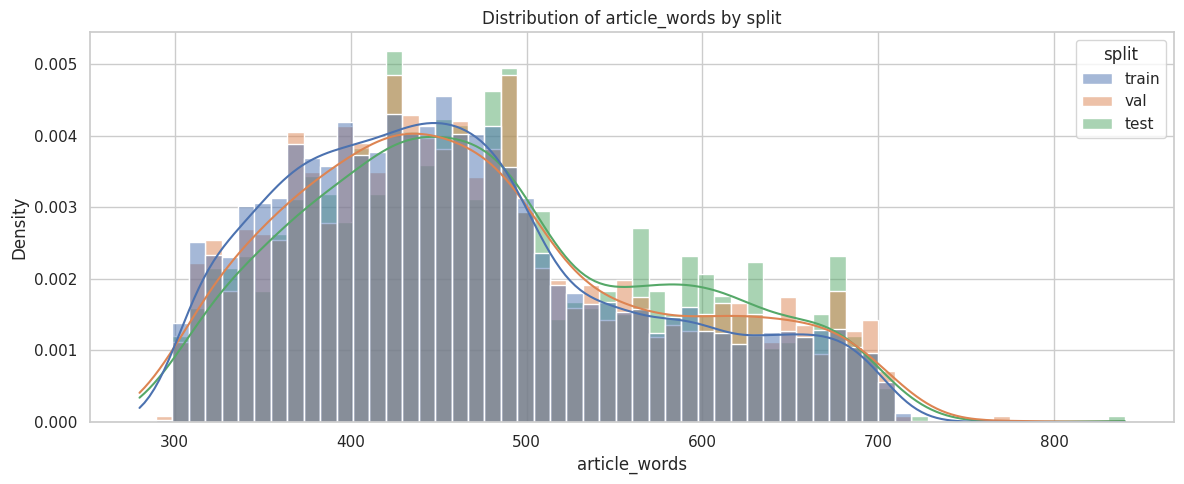

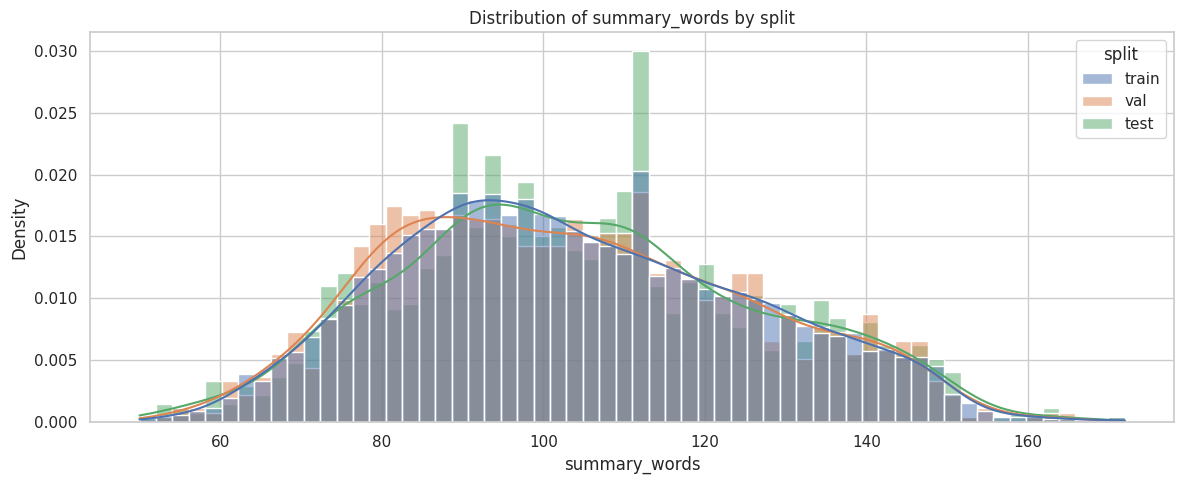

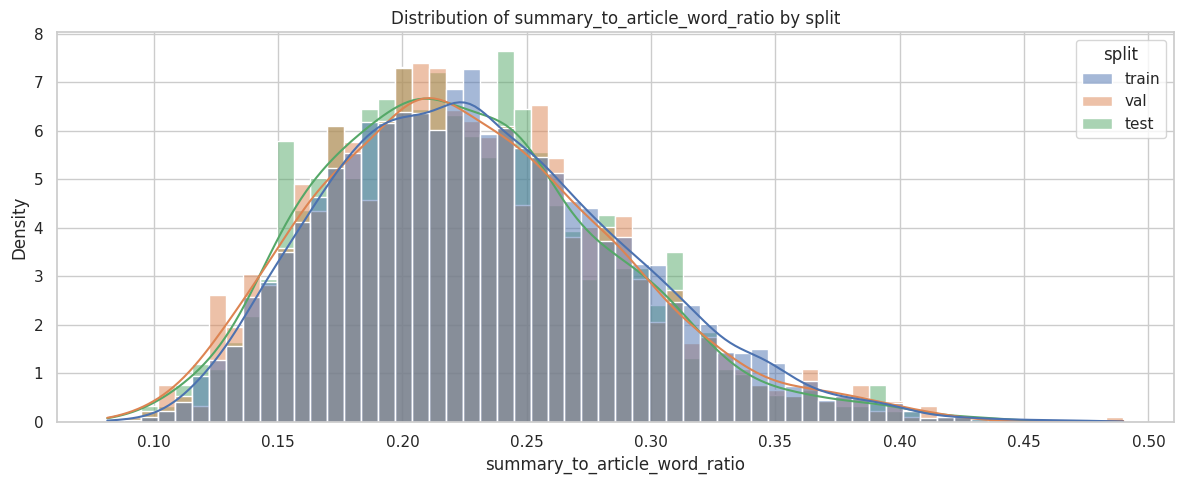

In [11]:
for col in ["article_words", "summary_words", "summary_to_article_word_ratio"]:
    if col in combined_eda.columns:
        plt.figure(figsize=(12, 5))
        sns.histplot(
            data=combined_eda.dropna(subset=[col]),
            x=col,
            hue="split",
            bins=60,
            kde=True,
            stat="density",
            common_norm=False,
        )
        plt.title(f"Distribution of {col} by split")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.tight_layout()
        plt.show()

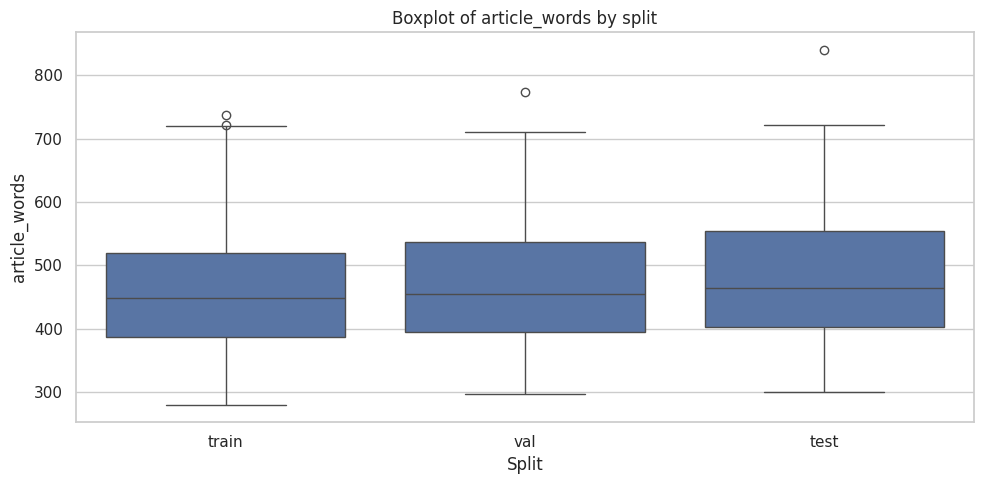

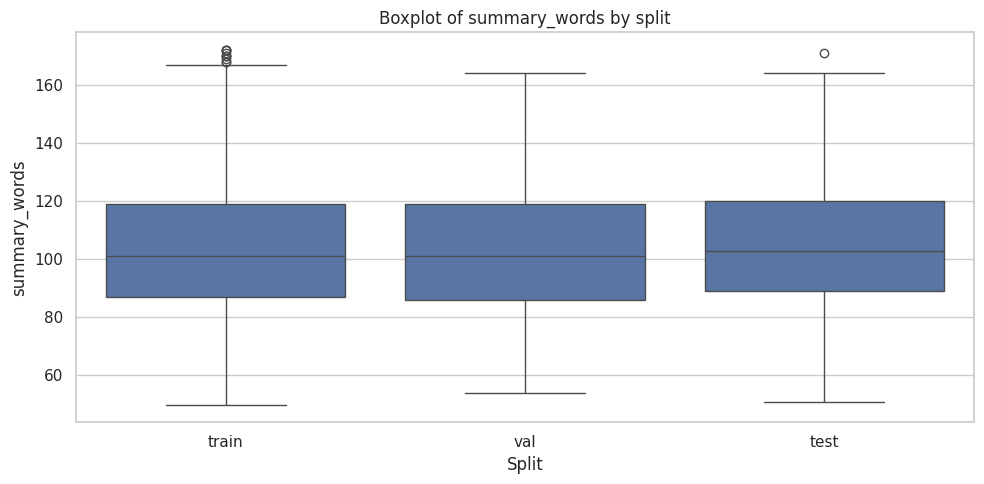

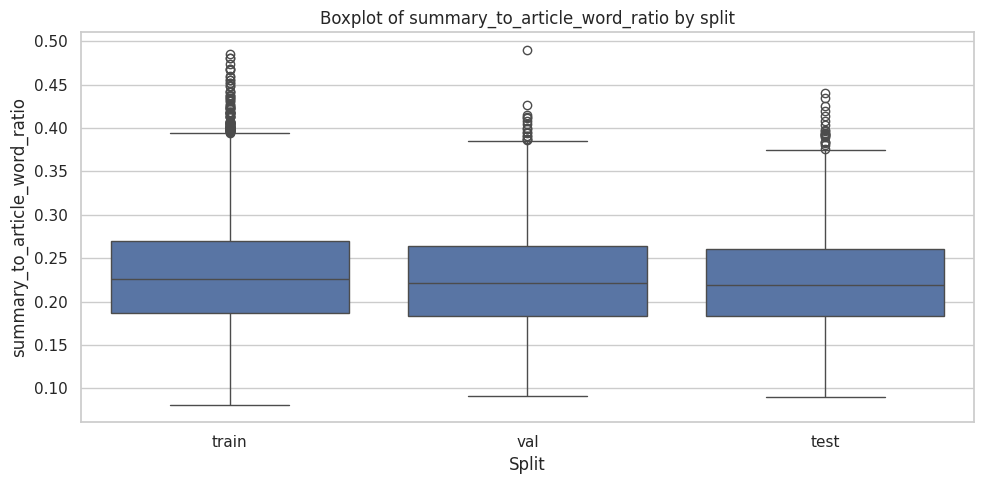

In [12]:
for col in ["article_words", "summary_words", "summary_to_article_word_ratio"]:
    if col in combined_eda.columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=combined_eda, x="split", y=col)
        plt.title(f"Boxplot of {col} by split")
        plt.xlabel("Split")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

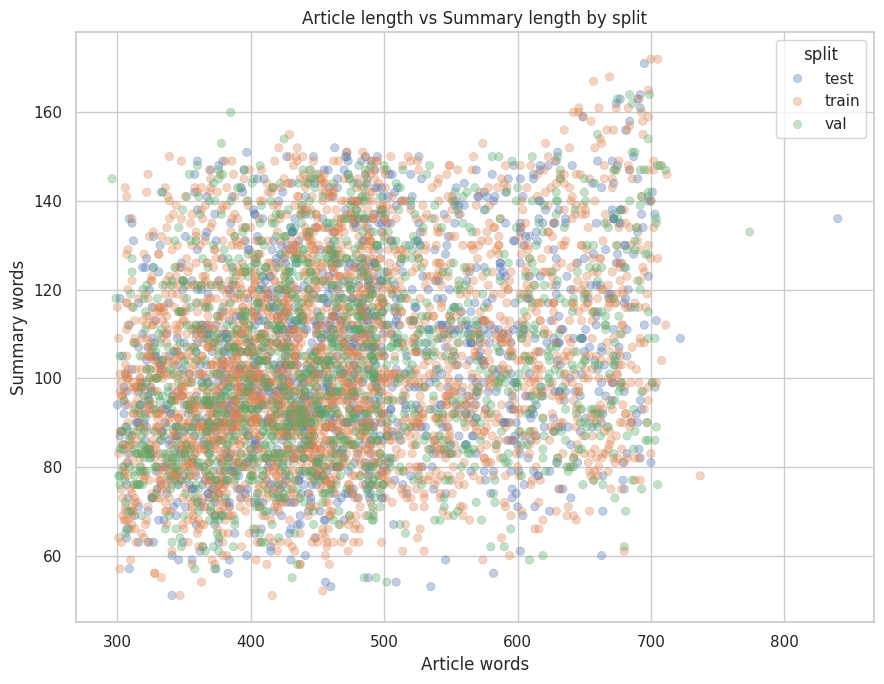

In [13]:
if {"article_words", "summary_words"}.issubset(combined_eda.columns):
    # Sample để scatter plot không quá nặng nếu dataset lớn.
    sampled = pd.concat([
        split_df.sample(min(len(split_df), 3000), random_state=42)
        for _, split_df in combined_eda.groupby("split")
    ], ignore_index=True)

    plt.figure(figsize=(9, 7))
    sns.scatterplot(
        data=sampled,
        x="article_words",
        y="summary_words",
        hue="split",
        alpha=0.35,
        edgecolor=None,
    )
    plt.title("Article length vs Summary length by split")
    plt.xlabel("Article words")
    plt.ylabel("Summary words")
    plt.tight_layout()
    plt.show()

## 10. Phát hiện outlier độ dài

Bạn có thể dùng bảng này để rà soát các mẫu quá ngắn/quá dài hoặc summary dài bất thường so với article.

In [14]:
def add_outlier_flags(df: pd.DataFrame) -> pd.DataFrame:
    flagged = df.copy()
    if "article_words" in flagged.columns:
        flagged["very_short_article"] = flagged["article_words"] <= 20
        flagged["very_long_article"] = flagged["article_words"] >= flagged["article_words"].quantile(0.99)
    if "summary_words" in flagged.columns:
        flagged["very_short_summary"] = flagged["summary_words"] <= 5
        flagged["very_long_summary"] = flagged["summary_words"] >= flagged["summary_words"].quantile(0.99)
    if "summary_to_article_word_ratio" in flagged.columns:
        flagged["high_summary_article_ratio"] = flagged["summary_to_article_word_ratio"] >= flagged["summary_to_article_word_ratio"].quantile(0.99)
    return flagged

flagged_dfs = {split: add_outlier_flags(df) for split, df in eda_dfs.items()}
flagged_combined = pd.concat(
    [df.assign(split=split) for split, df in flagged_dfs.items()],
    ignore_index=True,
)

flag_cols = [col for col in flagged_combined.columns if col.startswith("very_") or col.startswith("high_")]
outlier_summary = flagged_combined.groupby("split")[flag_cols].sum().astype(int)
display(outlier_summary)

,very_short_article,very_long_article,very_short_summary,very_long_summary,high_summary_article_ratio
split,,,,,
test,0,15,0,21,14
train,0,110,0,110,108
val,0,19,0,15,14


## 11. Xem ví dụ cực trị theo từng split

In [15]:
preview_cols = [
    col for col in [
        "split", "article_words", "summary_words", "summary_to_article_word_ratio", "article", "summary"
    ]
    if col in flagged_combined.columns
]

def show_examples(title: str, rows: pd.DataFrame, n: int = 5) -> None:
    print("\n" + "=" * 90)
    print(title)
    display(rows[preview_cols].head(n))

for split, split_df in flagged_combined.groupby("split"):
    print("\n" + "#" * 100)
    print(f"SPLIT: {split.upper()}")
    if "article_words" in split_df.columns:
        show_examples("Shortest articles", split_df.sort_values("article_words"))
        show_examples("Longest articles", split_df.sort_values("article_words", ascending=False))
    if "summary_words" in split_df.columns:
        show_examples("Shortest summaries", split_df.sort_values("summary_words"))
        show_examples("Longest summaries", split_df.sort_values("summary_words", ascending=False))
    if "summary_to_article_word_ratio" in split_df.columns:
        show_examples("Highest summary/article word ratios", split_df.sort_values("summary_to_article_word_ratio", ascending=False))


####################################################################################################
SPLIT: TEST

Shortest articles


,split,article_words,summary_words,summary_to_article_word_ratio,article,summary
13374,test,300,94,0.313333,"Trả lời: Nước dừa rất phổ biến với mẹ bầu, giàu vitamin A, E, canxi, kali, clorua,... giúp cải thiện sức khỏe và tăng cường miễn dịch. Nhiều mẹ bổ sung nước...","Nước dừa giàu vitamin và khoáng chất tốt cho sức khỏe, nhưng mẹ bầu nên hạn chế uống, đặc biệt trong 3 tháng đầu vì tính hàn và lượng đường cao có thể gây k..."
12755,test,302,118,0.390728,"Tôi 50 tuổi, có gia đình với hai con. Hiện tôi sở hữu một căn nhà tại TP HCM khoảng 6 tỷ đồng, cho thuê với giá 20 triệu mỗi tháng và một căn hộ chung cư để...","Tác giả đang cân nhắc việc rút 5 tỷ đồng gửi ngân hàng để đầu tư vào lĩnh vực khác có tỷ suất sinh lời cao hơn. Hiện tại, tác giả có 5 tỷ đồng gửi ngân hàng..."
13453,test,302,87,0.288079,"Phát biểu tại buổi ký kết, ông Henry Zou, Giám đốc Jomoo Việt Nam cho biết rất vinh dự được hiện hiện ở công trình thể hiện ""ý nghĩa của niềm hy vọng, của l...","Giám đốc Jomoo Việt Nam, ông Henry Zou, đã ký kết hợp với trường Hy Vọng để tài trợ cho các em học sinh nhỏ mồ côi. Ông hy vọng việc này sẽ mang lại sự khác..."
12734,test,303,88,0.290429,"Chương trình khuyến mại với ""Vòng quay may mắn"" diễn ra trên ứng dụng Agribank Plus. Khách hàng mở và sử dụng Tài khoản Plus, thực hiện giao dịch trong thời...","Văn bản chương trình khuyến mại ""Vòng quay may mắn"" của Agribank diễn ra trên ứng dụng Agribank Plus. Khách hàng mở và sử dụng Tài khoản Plus sẽ nhận lượt q..."
12522,test,304,85,0.279605,"TheoThe Information, Apple có thể gây bất ngờ lớn với các mẫuiPhone 17ra mắt vào tháng 9 năm sau khi từ bỏ việc sử dụng khung titan chỉ sau hai thế hệ. Nguy...","Apple có thể sẽ từ bỏ sử dụng khung titan và thay thế bằng nhôm cho iPhone 17. Mặt lưng được kết hợp giữa nhôm và kính, thay thế sử dụng kính như trước. Cụm..."



Longest articles


,split,article_words,summary_words,summary_to_article_word_ratio,article,summary
13100,test,840,136,0.161905,"Căn hộ có diện tích 90 m2, tọa lạc tại một tòa chung cư thuộc Thủ Đức (TP HCM). Công năng chính gồm phòng khách, bếp - ăn, hai phòng ngủ nhỏ, phò...","Căn hộ có diện tích 90 m2, tọa lạc tại một tòa chung cư thuộc Thủ Đức (TP HCM). Để đáp ứng nhu cầu của gia chủ, nhóm KTS đã bố trí lại toàn bộ công năng, tạ..."
12320,test,722,109,0.150970,"Hôm 17/12 (giờ California, tức sáng 18/12 giờ Hà Nội), Viện Hàn lâm Khoa học và Nghệ thuật Điện ảnh Mỹ công bố danh sách rút gọn của 10 hạng mục Oscar. Theo...","Văn bản này nói về việc Viện Hàn lâm Khoa học và Nghệ thuật Điện ảnh Mỹ công bố danh sách rút gọn của 10 hạng mục Oscar. Trong đó, phim ""Gia tài của ngoại"" ..."
12318,test,704,113,0.160511,"Đạo diễn xuất hiện trong buổi ra mắtYêu nhầm bạn thân(Kaity Nguyễn, Ngọc Vàng, Thanh Sơn đóng) với vai trò đồng sản xuất, chiều 16/12 tại TP HCM. Dự án là p...","Hôm tắt văn bản:\nTrấn Thành, đạo diễn nổi tiếng Việt Nam, vừa ra mắt phim Yêu nhầm bạn thân (Kaity Nguyễn, Ngọc Vàng, Thanh Sơn đóng) với vai trò đồng sản ..."
12254,test,703,137,0.194879,"Theo trangLTN, người đẹp 42 tuổi duy trì phát hành ảnh lịch mỗi dịp năm mới. Khi công bố một số bức trongbộ lịch 2025, cô nhận nhiều lời khen gợi cảm, lối t...",Fukada Kyoko là một diễn viên Nhật Bản nổi tiếng với sự thành công trong lĩnh vực thời trang và phim ảnh. Cô đã phát hành 21 bộ sách ảnh và từng lập kỷ lục ...
12867,test,703,98,0.139403,"Cẩm nang Michelin lần đầu đến Đà Nẵng vào tháng 6, gọi tên 35 nhà hàng, quán ăn vào danh sách, trong đó có 7 quán bình dân được tuyển chọn và gợi ý. Quán Bà...","Cẩm nang Michelin đã lần đầu tiên đến Đà Nẵng vào tháng 6, giới thiệu 35 nhà hàng và quán ăn, trong đó có 7 quán bình dân được gợi ý. Một số quán nổi bật ba..."



Shortest summaries


...

,split,article_words,summary_words,summary_to_article_word_ratio,article,summary
11597,val,502,54,0.107570,"'Tôi hai đứa con, đứa đầu năm nay học lớp 10, đứa sau lớp 2. Đứa đầu tôi chỉ chính thức cho đi học thêm từ lớp 8, nhưng chỉ học thêm ở trung tâm chứ chưa ba...",Người cha này chia sẻ rằng con mình không học thêm với giáo viên trong trường nhưng vẫn đạt điểm cao nhất lớp và đứng thứ 3 toàn trường. Ông cho rằng việc h...
11794,val,485,55,0.113402,"Lần đầu tiên mùa giải này, Ronaldo ghi hai bàn ở hai trận liên tiếp cho Al Nassr. Gặp Damac, siêu sao 39 tuổi mở tỷ số từ bàn phạt đền thứ 170 trong sự nghi...","Cristiano Ronaldo ghi hai bàn thắng giúp Al Nassr đánh bại Damac, nâng tổng số bàn thắng trong sự nghiệp lên 915 bàn. Chiến thắng này giúp Al Nassr rút ngắ..."
10913,val,431,55,0.127610,"Nhiếp ảnh gia Nguyễn Long cùng người thân, hội phù rể đi từ quận 2 sang quận Bình Tân để rước dâu. Khoảng 8h, đoàn nhà trai có mặt tại nhà gái, lần lượt tra...","Nhiếp ảnh gia Nguyễn Long cùng người thân, hội phù rể đi từ quận 2 sang quận Bình Tân để rước dâu. Cô dâu - chú rể diện áo dài phong cách truyền thống. Hội ..."
11817,val,494,55,0.111336,"Phút 68, khi Real đang bị dẫn 0-1, trung vệAntonio Rudigerbị thủ môn Julen Agirrezabala đấm vào gáy trong vòng cấm và mang về quả phạt đền. Từ chấm 11 mét, ...","Real Madrid để thua Athletic Bilbao 1-2 trên sân khách. Mbappe đá hỏng phạt đền và bỏ lỡ nhiều cơ hội ghi bàn, trong khi Bellingham ghi bàn gỡ hòa. Tuy nh..."
11863,val,373,57,0.152815,"Lần thứ tư liên tiếp, Alcaraz đánh bại Medvedev. Tay vợt Nga sau trận thừa nhận bất lực trong việc chống đỡ những pha tấn công của đàn em 21 tuổi. Khi bắt t...","Carlos Alcaraz đã đánh bại Daniil Medvedev lần thứ tư liên tiếp tại bán kết giải quần vợt Bắc Kinh mở rộng, với tỷ số 7-5, 6-3, dù Medvedev đã chơi tốt. ..."



Longest summaries


,split,article_words,summary_words,summary_to_article_word_ratio,article,summary
11248,val,699,164,0.234621,"White Shark Café là tên một địa điểm gặp gỡ bí ẩn của cá mập trắng (Carcharodon carcharias) nằm ở Thái Bình Dương, giữa Baja California và Hawaii. Những con...","White Shark Café là một địa điểm bí ẩn ở Thái Bình Dương, giữa Baja California và Hawaii, nơi cá mập trắng tụ tập mỗi năm. Các nhà khoa học đã theo dõi hành..."
11068,val,684,164,0.239766,Đây là lần đầu tiên vở ballet này được giới thiệu tại Việt Nam. The Seasons Ballet hình thành từ ý tưởng của ông Laurent Brunner – Giám đốc công ty Château ...,"The Seasons Ballet, một vở ballet độc đáo, được giới thiệu lần đầu tiên tại Việt Nam với sự kết hợp giữa âm nhạc cổ điển và vũ điệu ballet đương đại. Vở bal..."
10991,val,675,163,0.241481,"TheoKoreaboongày 25/10, sau một tuần ra mắt,APT.đứng đầu danh sách nghe nhiều nhất nền tảng iTunes toàn cầu, giữ vị trí số một bảng xếp hạng Apple Music tại...","Rosé, thành viên của nhóm nhạc Blackpink, đã trở thành nữ ca sĩ Kpop đầu tiên đứng đầu danh sách nghe nhiều nhất nền tảng iTunes toàn cầu và giữ vị trí số m..."
10947,val,686,162,0.236152,Giải thưởng sẽ được Viện Hàn lâm Thụy Điển công bố vào 13h ngày 10/10 (giờ địa phương). Người chiến thắng nhận phần thưởng 11 triệu krona Thụy Điển (26 tỷ đ...,"Tân Tuyết, nhà văn 71 tuổi của Trung Quốc, được dự đoán có khả năng đoạt giải Nobel Văn học năm 2023. Bà đứng đầu danh sách dự đoán của Nicer Odds với tỷ lệ..."
11081,val,385,160,0.415584,"Sự kiện do báoSài Gòn Giải Phóngvà Hội Nghệ sĩ Nhiếp ảnh Việt Nam (VAPA) phối hợp tổ chức, hướng đến 50 năm thống nhất đất nước (30/4/1975-30/4/2025), 100 n...","Cuộc thi ảnh ""Thành tựu, Cống hiến, Nước non ngàn dặm, Phát triển xanh, Vì trẻ thơ"" do báo Sài Gòn Giải Phóng và Hội Nghệ sĩ Nhiếp ảnh Việt Nam (VAPA) phối ..."



Highest summary/article word ratios


,split,article_words,summary_words,summary_to_article_word_ratio,article,summary
11041,val,296,145,0.489865,"Là khách mời của show Timeless tối 17/11, Á hậu Miss Universe Vietnam 2024 Quỳnh Anh diện đầm corset với điểm nhấn hoa 3D ở ngực. Là khách mời của show Time...","Là khách mời của show Timeless tối 17/11, Á hậu Miss Universe Vietnam 2024 Quỳnh Anh diện đầm corset với điểm nhấn hoa 3D ở ngực. Diễn viên Khả Ngân chọn đầ..."
11161,val,333,142,0.426426,"Theo công bố trên website của Samsung, Galaxy Z Fold Special Edition có thiết kế không khác biệt so với Galaxy Z Fold6 ngoài cụm camera sau và mặt lưng vân ...","Samsung đã giới thiệu phiên bản đặc biệt của Galaxy Z Fold, được gọi là Galaxy Z Fold Special Edition. Đây là phiên bản được thiết kế mỏng hơn so với Galaxy..."
11081,val,385,160,0.415584,"Sự kiện do báoSài Gòn Giải Phóngvà Hội Nghệ sĩ Nhiếp ảnh Việt Nam (VAPA) phối hợp tổ chức, hướng đến 50 năm thống nhất đất nước (30/4/1975-30/4/2025), 100 n...","Cuộc thi ảnh ""Thành tựu, Cống hiến, Nước non ngàn dặm, Phát triển xanh, Vì trẻ thơ"" do báo Sài Gòn Giải Phóng và Hội Nghệ sĩ Nhiếp ảnh Việt Nam (VAPA) phối ..."
11139,val,354,146,0.412429,Buổi triển lãm diễn ra vào thứ Bảy ngày 21/9 tại Khách sạn Daewoo (Hà Nội) và Chủ nhật ngày 22/9 tại Khách sạn Sofitel Saigon Plaza (TP HCM). Sự kiện quy tụ...,Buổi triển lãm du học Mỹ được tổ chức tại hai địa điểm: Khách sạn Daewoo (Hà Nội) và Khách sạn Sofitel Saigon Plaza (TP HCM). Sự kiện thu hút nhiều trường T...
11215,val,360,148,0.411111,Nga bắt đầu sản xuất hàng loạt hầm trú bom di động có thể bảo vệ người trước tác động có hại của bức xạ trong suốt 48 giờ trong trường hợp xảy ra vụ tấn côn...,"Nga đã bắt đầu sản xuất hầm trú bom di động có sức chứa 54 người, có thể bảo vệ người trước tác động của bức xạ trong 48 giờ. Hầm trú ẩn này được thiết kế đ..."


## 12. Token phổ biến theo từng split

Tokenizer dưới đây được viết đơn giản, không phụ thuộc thư viện NLP ngoài. Với tiếng Việt, kết quả đủ tốt cho EDA nhanh, nhưng không thay thế tokenizer chuyên biệt như VnCoreNLP/underthesea khi tiền xử lý chính thức.

In [16]:
VIETNAMESE_STOPWORDS = {
    "và", "là", "của", "có", "cho", "trong", "được", "với", "các", "những", "một", "này", "đã",
    "khi", "từ", "tại", "về", "để", "theo", "sẽ", "năm", "người", "không", "cũng", "đến",
    "trên", "sau", "nhiều", "ra", "vào", "ở", "nơi", "đó", "nên", "hơn", "nữa", "như", "do",
    "bị", "vì", "nếu", "thì", "hay", "rằng", "nói", "ông", "bà", "anh", "chị", "em", "tôi",
}

ENGLISH_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "he", "in", "is", "it",
    "its", "of", "on", "that", "the", "to", "was", "were", "will", "with", "this", "these", "those",
    "or", "not", "but", "they", "their", "his", "her", "she", "you", "we", "our", "have", "had", "been",
}

STOPWORDS = VIETNAMESE_STOPWORDS | ENGLISH_STOPWORDS

# Dải ký tự À-ỹ bao phủ phần lớn chữ cái tiếng Việt có dấu.
TOKEN_PATTERN = re.compile(r"[A-Za-zÀ-ỹ]+", flags=re.UNICODE)

def tokenize_text(values: pd.Series, max_rows: int = 20000) -> list[str]:
    sample = values.dropna().astype(str).head(max_rows)
    tokens = []
    for text in sample:
        for token in TOKEN_PATTERN.findall(text.lower()):
            if token not in STOPWORDS and len(token) > 1:
                tokens.append(token)
    return tokens

def top_tokens(values: pd.Series, n: int = 25, max_rows: int = 20000) -> pd.DataFrame:
    counts = Counter(tokenize_text(values, max_rows=max_rows))
    return pd.DataFrame(counts.most_common(n), columns=["token", "count"])

token_tables = {}
for split, df in dfs.items():
    token_tables[split] = {}
    for col in TEXT_COLUMNS:
        if col in df.columns:
            table = top_tokens(df[col], n=25)
            token_tables[split][col] = table
            display(table.style.set_caption(f"Top tokens | split={split} | column={col}"))

,token,count
0,công,24673
1,đầu,20813
2,nhà,20576
3,thể,19894
4,đồng,18623
5,số,16708
6,động,15334
7,thành,14728
8,hai,14443
9,giá,14101


,token,count
0,công,6280
1,đồng,4433
2,nhà,4375
3,đầu,4251
4,thể,4194
5,sự,4160
6,giá,4128
7,động,3978
8,việc,3615
9,thành,3562


,token,count
0,công,3047
1,nhà,2699
2,đầu,2593
3,thể,2535
4,đồng,2333
5,số,2088
6,thành,1968
7,giá,1928
8,hai,1889
9,động,1885


,token,count
0,công,720
1,đồng,549
2,nhà,527
3,giá,521
4,đầu,511
5,thể,496
6,thành,489
7,động,474
8,hiện,461
9,sự,457


,token,count
0,công,3321
1,đầu,2678
2,thể,2582
3,nhà,2559
4,đồng,2446
5,động,2023
6,số,1975
7,thành,1956
8,sự,1885
9,giá,1871


,token,count
0,công,847
1,đồng,592
2,sự,575
3,thể,553
4,giá,549
5,nhà,534
6,đầu,525
7,động,501
8,việc,485
9,thành,440


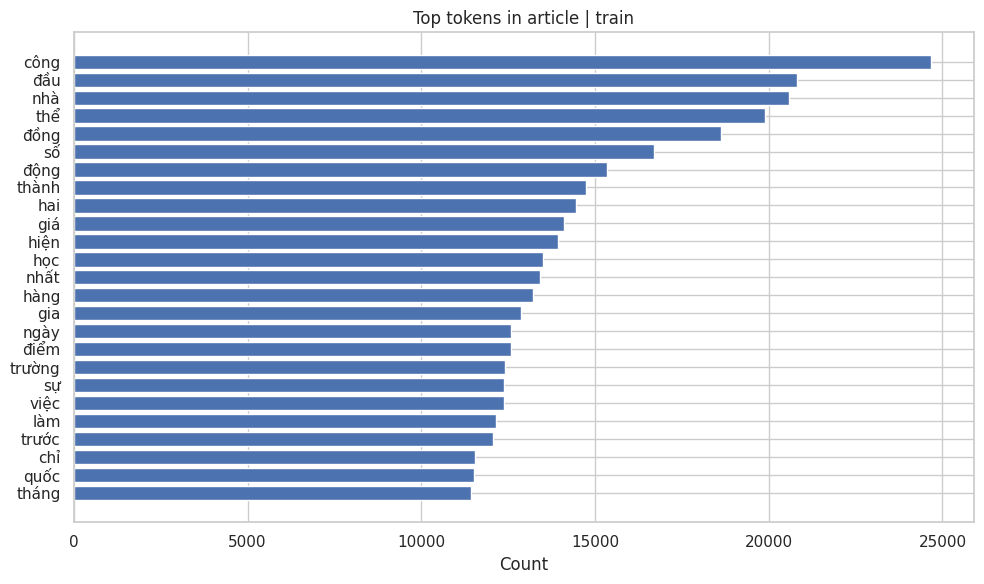

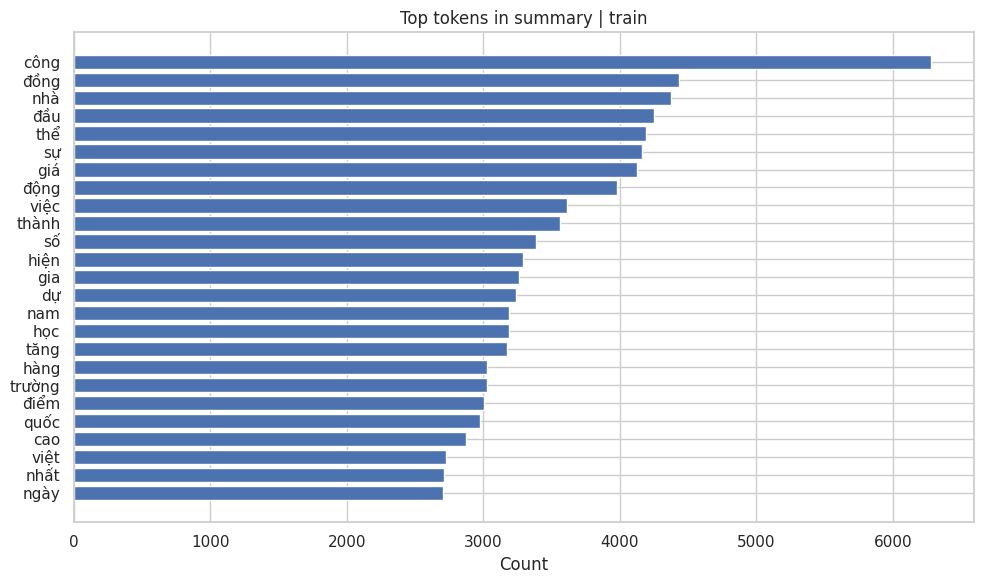

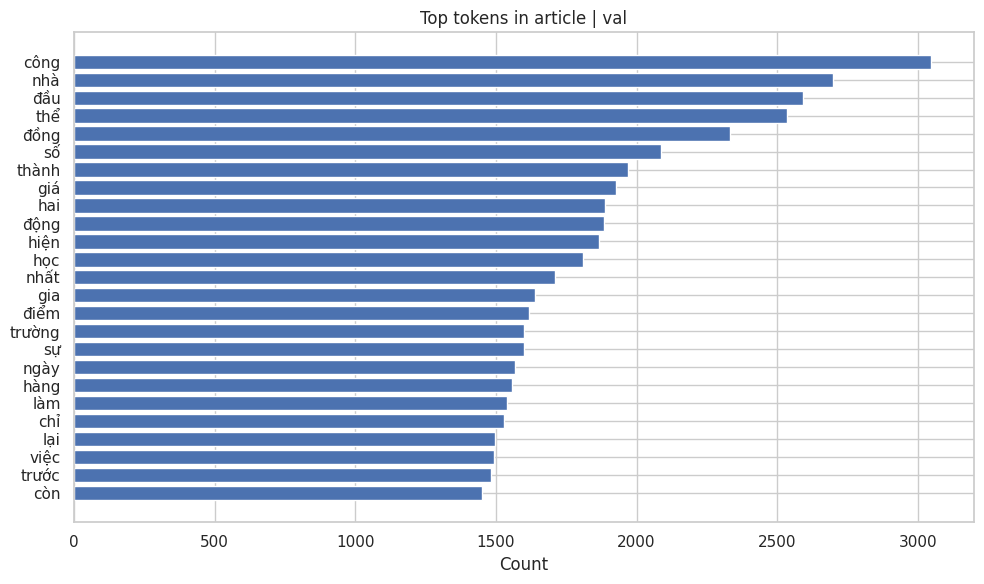

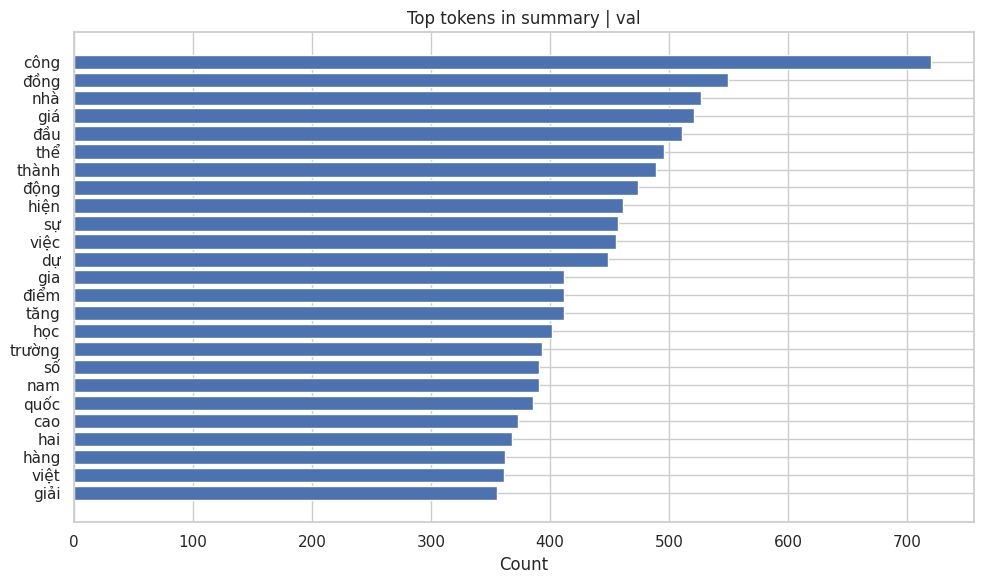

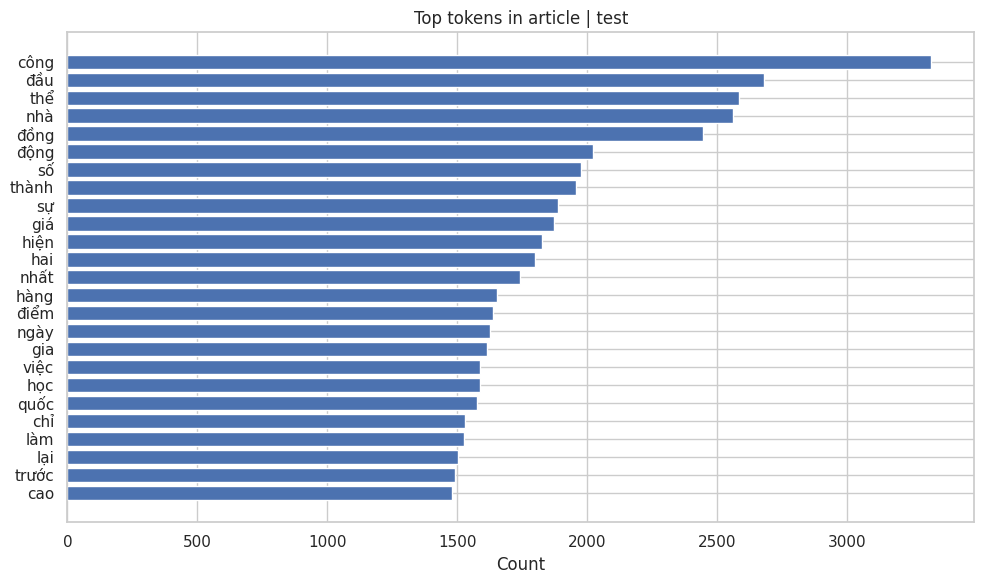

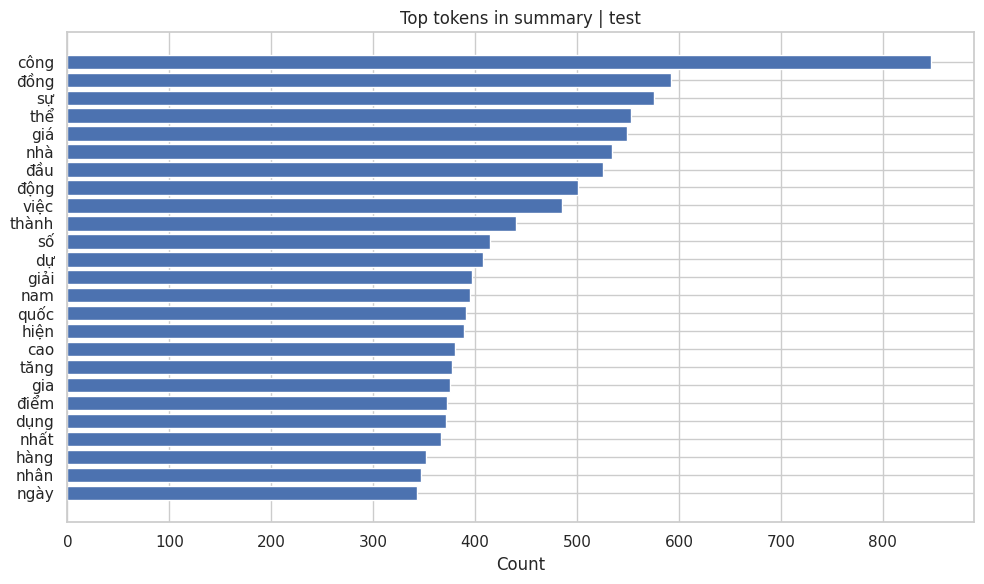

In [17]:
for split, col_tables in token_tables.items():
    for col, table in col_tables.items():
        if table.empty:
            continue

        # Dùng matplotlib barh để tránh lỗi màu mặc định của một số phiên bản seaborn/matplotlib.
        plot_table = table.sort_values("count", ascending=True)
        plt.figure(figsize=(10, 6))
        plt.barh(plot_table["token"], plot_table["count"])
        plt.title(f"Top tokens in {col} | {split}")
        plt.xlabel("Count")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

## 13. So sánh nhanh vocabulary giữa các split

In [18]:
def token_set(values: pd.Series, max_rows: int = 20000) -> set[str]:
    return set(tokenize_text(values, max_rows=max_rows))

vocab_rows = []
for col in TEXT_COLUMNS:
    if all(col in df.columns for df in dfs.values()):
        vocabs = {split: token_set(df[col]) for split, df in dfs.items()}
        for split, vocab in vocabs.items():
            vocab_rows.append({"column": col, "split": split, "vocab_size": len(vocab)})
        for i, split_a in enumerate(split_names):
            for split_b in split_names[i + 1:]:
                a, b = vocabs[split_a], vocabs[split_b]
                union = a | b
                inter = a & b
                vocab_rows.append({
                    "column": col,
                    "split": f"{split_a}∩{split_b}",
                    "vocab_size": len(inter),
                    "jaccard_with_pair": round(len(inter) / len(union), 4) if union else 0,
                })

vocab_summary = pd.DataFrame(vocab_rows)
display(vocab_summary)

,column,split,vocab_size,jaccard_with_pair
0,article,train,52920,NaN
1,article,val,14386,NaN
2,article,test,14388,NaN
3,article,train∩val,10068,0.1759
4,article,train∩test,10002,0.1745
5,article,val∩test,6852,0.3126
6,summary,train,17439,NaN
7,summary,val,5747,NaN
8,summary,test,5710,NaN
9,summary,train∩val,4680,0.2529


## 14. Xuất bảng EDA ra CSV để dùng trong báo cáo

Cell này tạo các file `.csv` nhỏ chứa kết quả tổng hợp. Có thể bỏ qua nếu bạn chỉ cần xem trực tiếp trong notebook.

In [19]:
OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

size_summary.to_csv(OUTPUT_DIR / "size_summary.csv", encoding="utf-8-sig")
schema_summary.to_csv(OUTPUT_DIR / "schema_summary.csv", index=False, encoding="utf-8-sig")
quality_summary.to_csv(OUTPUT_DIR / "quality_summary.csv", encoding="utf-8-sig")
overlap_summary.to_csv(OUTPUT_DIR / "split_overlap_summary.csv", index=False, encoding="utf-8-sig")
compact_length_summary.to_csv(OUTPUT_DIR / "length_summary.csv", encoding="utf-8-sig")
outlier_summary.to_csv(OUTPUT_DIR / "outlier_summary.csv", encoding="utf-8-sig")
vocab_summary.to_csv(OUTPUT_DIR / "vocab_summary.csv", index=False, encoding="utf-8-sig")

print(f"Đã lưu các bảng EDA vào: {OUTPUT_DIR.resolve()}")

Đã lưu các bảng EDA vào: /content/eda_outputs


## 15. Ghi chú sau khi chạy

Sau khi chạy notebook, hãy điền nhanh các ý sau để đưa vào báo cáo:

- Kích thước từng split: train / val / test.
- Các cột có trong dataset và kiểu dữ liệu.
- Có missing/empty text hay không.
- Có duplicate trong từng split hoặc overlap giữa train-val-test hay không.
- Độ dài article/summary trung bình, median, p95, p99.
- Tỷ lệ nén summary/article có hợp lý không.
- Train/val/test có phân phối độ dài tương đồng không.
- Các outlier cần kiểm tra trước khi train/evaluate model.